<a href="https://colab.research.google.com/github/MLDreamer/Linkedin-posts/blob/main/Batch_window_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


INTERACTIVE BATCH WINDOW OPTIMIZER

Adjust constraints below and see results instantly:



interactive(children=(IntSlider(value=20, description='Capacity (kg):', max=40, min=10, step=5), FloatSlider(v…


WHAT-IF SCENARIOS

                             Scenario      CPD  Batches  Batching %  Savings %
        Standard (20kg, 5km, batch=3) 1.435761       10  100.000000  64.809335
   Small Vehicle (15kg, 5km, batch=3) 1.435761       10  100.000000  64.809335
   Large Vehicle (30kg, 5km, batch=4) 1.146251        8  100.000000  71.905256
Tight Clustering (20kg, 3km, batch=3) 1.555037       11   90.909091  61.885870
Loose Clustering (20kg, 8km, batch=3) 1.435761       10  100.000000  64.809335


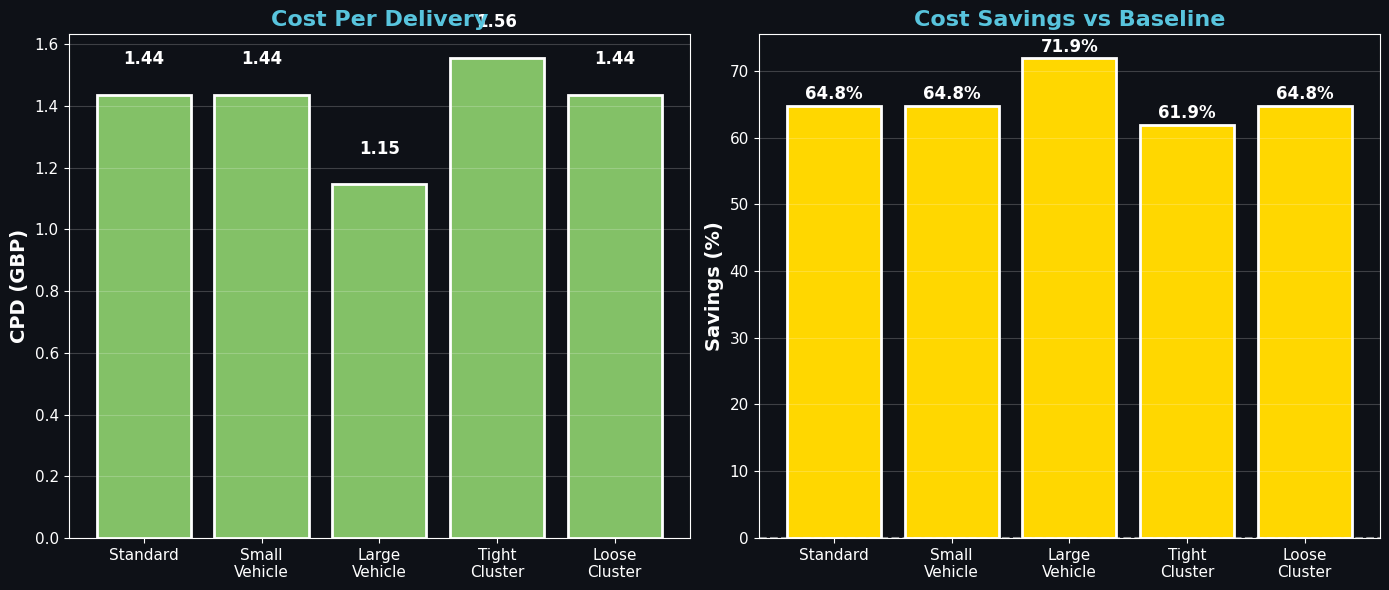


EXPERIMENTATION COMPLETE


In [1]:
"""
BATCH WINDOW OPTIMIZATION - INTERACTIVE EXPERIMENTATION
========================================================
Play with constraints and see results instantly
"""

import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                      "pulp", "matplotlib", "numpy", "pandas", "ipywidgets"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import *
from datetime import datetime, timedelta
from itertools import combinations, permutations
from ipywidgets import interact, FloatSlider, IntSlider
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
GREEN = '#83C167'
RED = '#FC6255'
CYAN = '#58C4DD'
YELLOW = '#FFD700'

# ============================================================================
# DATA GENERATOR
# ============================================================================

class OrderGenerator:
    def __init__(self, seed=42):
        np.random.seed(seed)
        self.store_lat = 51.5265
        self.store_lon = -0.0823

    def generate(self, n_orders=30, radius_km=3.0, lambda_rate=0.2):
        orders = []
        for i in range(n_orders):
            r = radius_km * np.sqrt(np.random.random())
            theta = 2 * np.pi * np.random.random()
            lat = self.store_lat + r * np.cos(theta) / 111.0
            lon = self.store_lon + r * np.sin(theta) / (111.0 * np.cos(np.radians(self.store_lat)))
            weight = np.random.uniform(0.5, 3.0)

            orders.append({
                'order_id': f'ORD{i+1:03d}',
                'customer_lat': lat,
                'customer_lon': lon,
                'weight_kg': weight
            })
        return pd.DataFrame(orders)

# ============================================================================
# OPTIMIZATION FUNCTIONS
# ============================================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def calc_cost(distance_km, fixed=3.50, variable=0.15):
    return fixed + variable * distance_km

def generate_batches(orders, capacity_kg, max_dist_km, max_batch_size):
    batches = []
    batch_id = 0

    for idx, order in orders.iterrows():
        batches.append({
            'batch_id': batch_id,
            'indices': [idx],
            'weight': order['weight_kg']
        })
        batch_id += 1

    for size in range(2, min(max_batch_size + 1, len(orders) + 1)):
        for combo in combinations(orders.iterrows(), size):
            indices, rows = zip(*combo)
            total_weight = sum(r['weight_kg'] for r in rows)

            if total_weight > capacity_kg:
                continue

            lats = [r['customer_lat'] for r in rows]
            lons = [r['customer_lon'] for r in rows]

            max_dist = 0
            for i in range(len(lats)):
                for j in range(i+1, len(lats)):
                    d = haversine(lats[i], lons[i], lats[j], lons[j])
                    max_dist = max(max_dist, d)

            if max_dist > max_dist_km:
                continue

            batches.append({
                'batch_id': batch_id,
                'indices': list(indices),
                'weight': total_weight
            })
            batch_id += 1

    return batches

def solve_tsp(batch_orders, store_lat, store_lon):
    n = len(batch_orders)

    if n == 1:
        order = batch_orders.iloc[0]
        dist = haversine(store_lat, store_lon, order['customer_lat'], order['customer_lon'])
        return dist * 2

    locs = [(store_lat, store_lon)]
    for _, r in batch_orders.iterrows():
        locs.append((r['customer_lat'], r['customer_lon']))

    n_nodes = len(locs)
    dist_mat = np.zeros((n_nodes, n_nodes))

    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                dist_mat[i][j] = haversine(locs[i][0], locs[i][1], locs[j][0], locs[j][1])

    if n <= 4:
        min_dist = float('inf')
        for perm in permutations(range(1, n_nodes)):
            route = [0] + list(perm) + [0]
            dist = sum(dist_mat[route[i]][route[i+1]] for i in range(len(route)-1))
            min_dist = min(min_dist, dist)
        return min_dist
    else:
        unvisited = set(range(1, n_nodes))
        route = [0]
        current = 0
        while unvisited:
            nearest = min(unvisited, key=lambda j: dist_mat[current][j])
            route.append(nearest)
            unvisited.remove(nearest)
            current = nearest
        route.append(0)
        return sum(dist_mat[route[i]][route[i+1]] for i in range(len(route)-1))

def optimize(orders, capacity_kg, max_dist_km, max_batch_size, store_lat, store_lon):
    batches = generate_batches(orders, capacity_kg, max_dist_km, max_batch_size)

    batch_info = []
    for batch in batches:
        batch_orders = orders.loc[batch['indices']]
        route_dist = solve_tsp(batch_orders, store_lat, store_lon)
        cost = calc_cost(route_dist)

        batch_info.append({
            'batch_id': batch['batch_id'],
            'n_orders': len(batch['indices']),
            'total_cost': cost,
            'cost_per_order': cost / len(batch['indices'])
        })

    assigned = set()
    selected = []

    for batch in sorted(batch_info, key=lambda x: x['cost_per_order']):
        indices = batches[batch['batch_id']]['indices']
        if any(idx in assigned for idx in indices):
            continue
        selected.append(batch)
        assigned.update(indices)
        if len(assigned) == len(orders):
            break

    total_cost = sum(b['total_cost'] for b in selected)
    cpd = total_cost / len(orders)
    batching_rate = sum(1 for b in selected if b['n_orders'] > 1) / len(selected) * 100

    return {
        'cpd': cpd,
        'n_batches': len(selected),
        'batching_rate': batching_rate,
        'total_cost': total_cost
    }

def baseline(orders, store_lat, store_lon):
    total_cost = 0
    for _, order in orders.iterrows():
        dist = haversine(store_lat, store_lon, order['customer_lat'], order['customer_lon'])
        total_cost += calc_cost(dist * 2)

    return {
        'cpd': total_cost / len(orders),
        'n_batches': len(orders),
        'batching_rate': 0,
        'total_cost': total_cost
    }

# ============================================================================
# INTERACTIVE EXPERIMENTATION
# ============================================================================

gen = OrderGenerator(seed=42)
orders = gen.generate(n_orders=30, radius_km=3.0)

def experiment(capacity_kg=20, max_dist_km=5, max_batch_size=3):
    base = baseline(orders, gen.store_lat, gen.store_lon)
    opt = optimize(orders, capacity_kg, max_dist_km, max_batch_size, gen.store_lat, gen.store_lon)

    savings_pct = (1 - opt['cpd'] / base['cpd']) * 100
    de_reduction_pct = (1 - opt['n_batches'] / base['n_batches']) * 100

    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0E1117')
    ax.set_facecolor('#0E1117')

    metrics = ['CPD (GBP)', 'Batches/DEs', 'Batching Rate (%)']
    baseline_vals = [base['cpd'], base['n_batches'], base['batching_rate']]
    optimized_vals = [opt['cpd'], opt['n_batches'], opt['batching_rate']]

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline',
                   color=RED, edgecolor='white', linewidth=2)
    bars2 = ax.bar(x + width/2, optimized_vals, width, label='Optimized',
                   color=GREEN, edgecolor='white', linewidth=2)

    ax.set_ylabel('Value', fontsize=16, color='white', weight='bold')
    ax.set_title('Baseline vs Optimized Batching', fontsize=18,
                color=CYAN, weight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=14, color='white')
    ax.legend(fontsize=14, loc='upper right')
    ax.grid(True, alpha=0.2, axis='y')
    ax.tick_params(colors='white', labelsize=12)

    for i, (b, o) in enumerate(zip(baseline_vals, optimized_vals)):
        ax.text(i - width/2, b + 1, f'{b:.1f}', ha='center',
               fontsize=13, color='white', weight='bold')
        ax.text(i + width/2, o + 1, f'{o:.1f}', ha='center',
               fontsize=13, color='white', weight='bold')

    results_text = f"""
RESULTS:
• Cost Savings: {savings_pct:.1f}%
• DE Reduction: {de_reduction_pct:.1f}%
• Batching Rate: {opt['batching_rate']:.1f}%

PARAMETERS:
• Capacity: {capacity_kg} kg
• Max Distance: {max_dist_km} km
• Max Batch Size: {max_batch_size}
    """

    ax.text(0.98, 0.97, results_text, transform=ax.transAxes,
           fontsize=13, color=YELLOW, weight='bold',
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.9, pad=1))

    plt.tight_layout()
    plt.show()

    print(f"\nBASELINE: GBP {base['cpd']:.2f} per delivery | {base['n_batches']} DEs")
    print(f"OPTIMIZED: GBP {opt['cpd']:.2f} per delivery | {opt['n_batches']} batches")
    print(f"SAVINGS: {savings_pct:.1f}% cost | {de_reduction_pct:.1f}% DEs\n")

print("\n" + "="*60)
print("INTERACTIVE BATCH WINDOW OPTIMIZER")
print("="*60)
print("\nAdjust constraints below and see results instantly:\n")

interact(experiment,
         capacity_kg=IntSlider(min=10, max=40, step=5, value=20,
                              description='Capacity (kg):'),
         max_dist_km=FloatSlider(min=2, max=10, step=0.5, value=5,
                                description='Max Dist (km):'),
         max_batch_size=IntSlider(min=2, max=5, step=1, value=3,
                                 description='Max Batch:'))

# ============================================================================
# WHAT-IF SCENARIOS
# ============================================================================

print("\n" + "="*60)
print("WHAT-IF SCENARIOS")
print("="*60 + "\n")

scenarios = {
    'Standard (20kg, 5km, batch=3)': (20, 5, 3),
    'Small Vehicle (15kg, 5km, batch=3)': (15, 5, 3),
    'Large Vehicle (30kg, 5km, batch=4)': (30, 5, 4),
    'Tight Clustering (20kg, 3km, batch=3)': (20, 3, 3),
    'Loose Clustering (20kg, 8km, batch=3)': (20, 8, 3),
}

results = []
base = baseline(orders, gen.store_lat, gen.store_lon)

for name, (cap, dist, batch) in scenarios.items():
    opt = optimize(orders, cap, dist, batch, gen.store_lat, gen.store_lon)
    savings = (1 - opt['cpd'] / base['cpd']) * 100
    results.append({
        'Scenario': name,
        'CPD': opt['cpd'],
        'Batches': opt['n_batches'],
        'Batching %': opt['batching_rate'],
        'Savings %': savings
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0E1117')

for ax in axes:
    ax.set_facecolor('#0E1117')

scenarios_short = ['Standard', 'Small\nVehicle', 'Large\nVehicle',
                   'Tight\nCluster', 'Loose\nCluster']
cpds = df_results['CPD'].values
savings = df_results['Savings %'].values

axes[0].bar(scenarios_short, cpds, color=GREEN, edgecolor='white', linewidth=2)
axes[0].set_ylabel('CPD (GBP)', fontsize=14, color='white', weight='bold')
axes[0].set_title('Cost Per Delivery', fontsize=16, color=CYAN, weight='bold')
axes[0].tick_params(colors='white', labelsize=11)
axes[0].grid(True, alpha=0.2, axis='y')

for i, v in enumerate(cpds):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center',
                fontsize=12, color='white', weight='bold')

axes[1].bar(scenarios_short, savings, color=YELLOW, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Savings (%)', fontsize=14, color='white', weight='bold')
axes[1].set_title('Cost Savings vs Baseline', fontsize=16, color=CYAN, weight='bold')
axes[1].tick_params(colors='white', labelsize=11)
axes[1].grid(True, alpha=0.2, axis='y')
axes[1].axhline(y=0, color='white', linestyle='--', alpha=0.5)

for i, v in enumerate(savings):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center',
                fontsize=12, color='white', weight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EXPERIMENTATION COMPLETE")
print("="*60)


INTERACTIVE BATCH WINDOW OPTIMIZER

Adjust constraints below and see results instantly:



interactive(children=(IntSlider(value=20, description='Capacity (kg):', max=40, min=10, step=5), FloatSlider(v…


WHAT-IF SCENARIOS

                             Scenario      CPD  Batches  Batching %  Savings %
        Standard (20kg, 5km, batch=3) 1.435761       10  100.000000  64.809335
   Small Vehicle (15kg, 5km, batch=3) 1.435761       10  100.000000  64.809335
   Large Vehicle (30kg, 5km, batch=4) 1.146251        8  100.000000  71.905256
Tight Clustering (20kg, 3km, batch=3) 1.555037       11   90.909091  61.885870
Loose Clustering (20kg, 8km, batch=3) 1.435761       10  100.000000  64.809335


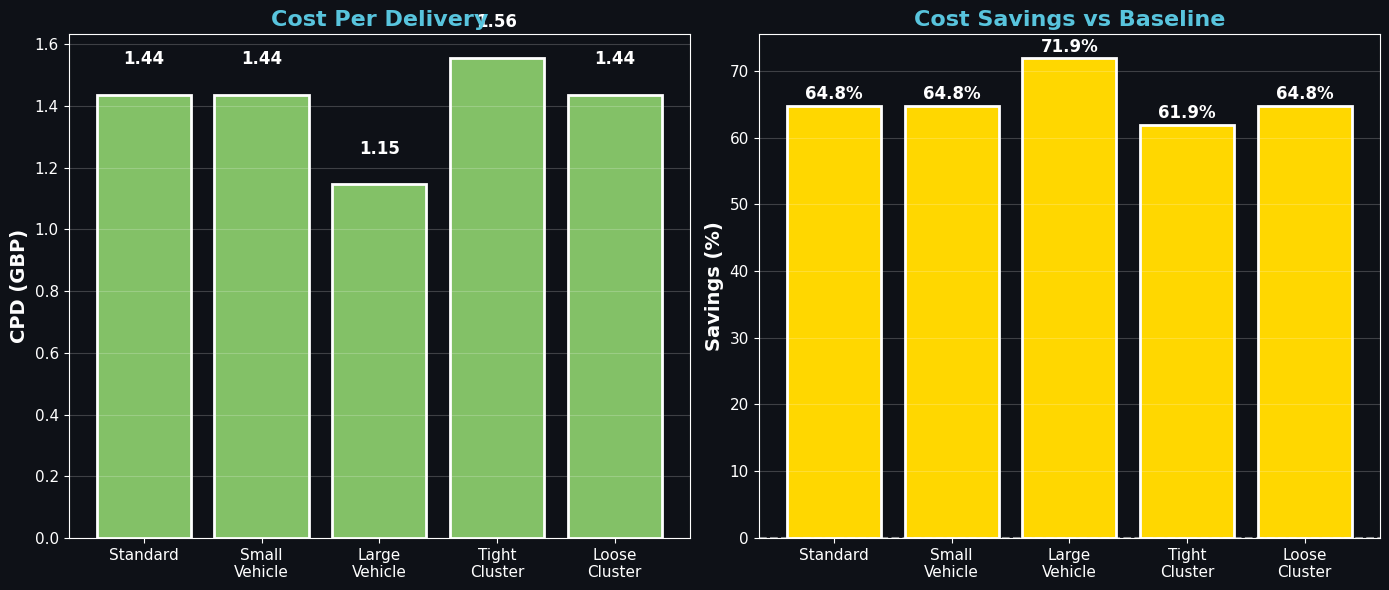


EXPERIMENTATION COMPLETE


In [ ]:
"""
BATCH WINDOW OPTIMIZATION - INTERACTIVE EXPERIMENTATION
========================================================
Play with constraints and see results instantly
"""

import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                      "pulp", "matplotlib", "numpy", "pandas", "ipywidgets"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import *
from datetime import datetime, timedelta
from itertools import combinations, permutations
from ipywidgets import interact, FloatSlider, IntSlider
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
GREEN = '#83C167'
RED = '#FC6255'
CYAN = '#58C4DD'
YELLOW = '#FFD700'

# ============================================================================
# DATA GENERATOR
# ============================================================================

class OrderGenerator:
    def __init__(self, seed=42):
        np.random.seed(seed)
        self.store_lat = 51.5265
        self.store_lon = -0.0823

    def generate(self, n_orders=30, radius_km=3.0, lambda_rate=0.2):
        orders = []
        for i in range(n_orders):
            r = radius_km * np.sqrt(np.random.random())
            theta = 2 * np.pi * np.random.random()
            lat = self.store_lat + r * np.cos(theta) / 111.0
            lon = self.store_lon + r * np.sin(theta) / (111.0 * np.cos(np.radians(self.store_lat)))
            weight = np.random.uniform(0.5, 3.0)

            orders.append({
                'order_id': f'ORD{i+1:03d}',
                'customer_lat': lat,
                'customer_lon': lon,
                'weight_kg': weight
            })
        return pd.DataFrame(orders)

# ============================================================================
# OPTIMIZATION FUNCTIONS
# ============================================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def calc_cost(distance_km, fixed=3.50, variable=0.15):
    return fixed + variable * distance_km

def generate_batches(orders, capacity_kg, max_dist_km, max_batch_size):
    batches = []
    batch_id = 0

    for idx, order in orders.iterrows():
        batches.append({
            'batch_id': batch_id,
            'indices': [idx],
            'weight': order['weight_kg']
        })
        batch_id += 1

    for size in range(2, min(max_batch_size + 1, len(orders) + 1)):
        for combo in combinations(orders.iterrows(), size):
            indices, rows = zip(*combo)
            total_weight = sum(r['weight_kg'] for r in rows)

            if total_weight > capacity_kg:
                continue

            lats = [r['customer_lat'] for r in rows]
            lons = [r['customer_lon'] for r in rows]

            max_dist = 0
            for i in range(len(lats)):
                for j in range(i+1, len(lats)):
                    d = haversine(lats[i], lons[i], lats[j], lons[j])
                    max_dist = max(max_dist, d)

            if max_dist > max_dist_km:
                continue

            batches.append({
                'batch_id': batch_id,
                'indices': list(indices),
                'weight': total_weight
            })
            batch_id += 1

    return batches

def solve_tsp(batch_orders, store_lat, store_lon):
    n = len(batch_orders)

    if n == 1:
        order = batch_orders.iloc[0]
        dist = haversine(store_lat, store_lon, order['customer_lat'], order['customer_lon'])
        return dist * 2

    locs = [(store_lat, store_lon)]
    for _, r in batch_orders.iterrows():
        locs.append((r['customer_lat'], r['customer_lon']))

    n_nodes = len(locs)
    dist_mat = np.zeros((n_nodes, n_nodes))

    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                dist_mat[i][j] = haversine(locs[i][0], locs[i][1], locs[j][0], locs[j][1])

    if n <= 4:
        min_dist = float('inf')
        for perm in permutations(range(1, n_nodes)):
            route = [0] + list(perm) + [0]
            dist = sum(dist_mat[route[i]][route[i+1]] for i in range(len(route)-1))
            min_dist = min(min_dist, dist)
        return min_dist
    else:
        unvisited = set(range(1, n_nodes))
        route = [0]
        current = 0
        while unvisited:
            nearest = min(unvisited, key=lambda j: dist_mat[current][j])
            route.append(nearest)
            unvisited.remove(nearest)
            current = nearest
        route.append(0)
        return sum(dist_mat[route[i]][route[i+1]] for i in range(len(route)-1))

def optimize(orders, capacity_kg, max_dist_km, max_batch_size, store_lat, store_lon):
    batches = generate_batches(orders, capacity_kg, max_dist_km, max_batch_size)

    batch_info = []
    for batch in batches:
        batch_orders = orders.loc[batch['indices']]
        route_dist = solve_tsp(batch_orders, store_lat, store_lon)
        cost = calc_cost(route_dist)

        batch_info.append({
            'batch_id': batch['batch_id'],
            'n_orders': len(batch['indices']),
            'total_cost': cost,
            'cost_per_order': cost / len(batch['indices'])
        })

    assigned = set()
    selected = []

    for batch in sorted(batch_info, key=lambda x: x['cost_per_order']):
        indices = batches[batch['batch_id']]['indices']
        if any(idx in assigned for idx in indices):
            continue
        selected.append(batch)
        assigned.update(indices)
        if len(assigned) == len(orders):
            break

    total_cost = sum(b['total_cost'] for b in selected)
    cpd = total_cost / len(orders)
    batching_rate = sum(1 for b in selected if b['n_orders'] > 1) / len(selected) * 100

    return {
        'cpd': cpd,
        'n_batches': len(selected),
        'batching_rate': batching_rate,
        'total_cost': total_cost
    }

def baseline(orders, store_lat, store_lon):
    total_cost = 0
    for _, order in orders.iterrows():
        dist = haversine(store_lat, store_lon, order['customer_lat'], order['customer_lon'])
        total_cost += calc_cost(dist * 2)

    return {
        'cpd': total_cost / len(orders),
        'n_batches': len(orders),
        'batching_rate': 0,
        'total_cost': total_cost
    }

# ============================================================================
# INTERACTIVE EXPERIMENTATION
# ============================================================================

gen = OrderGenerator(seed=42)
orders = gen.generate(n_orders=30, radius_km=3.0)

def experiment(capacity_kg=20, max_dist_km=5, max_batch_size=3):
    base = baseline(orders, gen.store_lat, gen.store_lon)
    opt = optimize(orders, capacity_kg, max_dist_km, max_batch_size, gen.store_lat, gen.store_lon)

    savings_pct = (1 - opt['cpd'] / base['cpd']) * 100
    de_reduction_pct = (1 - opt['n_batches'] / base['n_batches']) * 100

    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0E1117')
    ax.set_facecolor('#0E1117')

    metrics = ['CPD (GBP)', 'Batches/DEs', 'Batching Rate (%)']
    baseline_vals = [base['cpd'], base['n_batches'], base['batching_rate']]
    optimized_vals = [opt['cpd'], opt['n_batches'], opt['batching_rate']]

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline',
                   color=RED, edgecolor='white', linewidth=2)
    bars2 = ax.bar(x + width/2, optimized_vals, width, label='Optimized',
                   color=GREEN, edgecolor='white', linewidth=2)

    ax.set_ylabel('Value', fontsize=16, color='white', weight='bold')
    ax.set_title('Baseline vs Optimized Batching', fontsize=18,
                color=CYAN, weight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=14, color='white')
    ax.legend(fontsize=14, loc='upper right')
    ax.grid(True, alpha=0.2, axis='y')
    ax.tick_params(colors='white', labelsize=12)

    for i, (b, o) in enumerate(zip(baseline_vals, optimized_vals)):
        ax.text(i - width/2, b + 1, f'{b:.1f}', ha='center',
               fontsize=13, color='white', weight='bold')
        ax.text(i + width/2, o + 1, f'{o:.1f}', ha='center',
               fontsize=13, color='white', weight='bold')

    results_text = f"""
RESULTS:
• Cost Savings: {savings_pct:.1f}%
• DE Reduction: {de_reduction_pct:.1f}%
• Batching Rate: {opt['batching_rate']:.1f}%

PARAMETERS:
• Capacity: {capacity_kg} kg
• Max Distance: {max_dist_km} km
• Max Batch Size: {max_batch_size}
    """

    ax.text(0.98, 0.97, results_text, transform=ax.transAxes,
           fontsize=13, color=YELLOW, weight='bold',
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.9, pad=1))

    plt.tight_layout()
    plt.show()

    print(f"\nBASELINE: GBP {base['cpd']:.2f} per delivery | {base['n_batches']} DEs")
    print(f"OPTIMIZED: GBP {opt['cpd']:.2f} per delivery | {opt['n_batches']} batches")
    print(f"SAVINGS: {savings_pct:.1f}% cost | {de_reduction_pct:.1f}% DEs\n")

print("\n" + "="*60)
print("INTERACTIVE BATCH WINDOW OPTIMIZER")
print("="*60)
print("\nAdjust constraints below and see results instantly:\n")

interact(experiment,
         capacity_kg=IntSlider(min=10, max=40, step=5, value=20,
                              description='Capacity (kg):'),
         max_dist_km=FloatSlider(min=2, max=10, step=0.5, value=5,
                                description='Max Dist (km):'),
         max_batch_size=IntSlider(min=2, max=5, step=1, value=3,
                                 description='Max Batch:'))

# ============================================================================
# WHAT-IF SCENARIOS
# ============================================================================

print("\n" + "="*60)
print("WHAT-IF SCENARIOS")
print("="*60 + "\n")

scenarios = {
    'Standard (20kg, 5km, batch=3)': (20, 5, 3),
    'Small Vehicle (15kg, 5km, batch=3)': (15, 5, 3),
    'Large Vehicle (30kg, 5km, batch=4)': (30, 5, 4),
    'Tight Clustering (20kg, 3km, batch=3)': (20, 3, 3),
    'Loose Clustering (20kg, 8km, batch=3)': (20, 8, 3),
}

results = []
base = baseline(orders, gen.store_lat, gen.store_lon)

for name, (cap, dist, batch) in scenarios.items():
    opt = optimize(orders, cap, dist, batch, gen.store_lat, gen.store_lon)
    savings = (1 - opt['cpd'] / base['cpd']) * 100
    results.append({
        'Scenario': name,
        'CPD': opt['cpd'],
        'Batches': opt['n_batches'],
        'Batching %': opt['batching_rate'],
        'Savings %': savings
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0E1117')

for ax in axes:
    ax.set_facecolor('#0E1117')

scenarios_short = ['Standard', 'Small\nVehicle', 'Large\nVehicle',
                   'Tight\nCluster', 'Loose\nCluster']
cpds = df_results['CPD'].values
savings = df_results['Savings %'].values

axes[0].bar(scenarios_short, cpds, color=GREEN, edgecolor='white', linewidth=2)
axes[0].set_ylabel('CPD (GBP)', fontsize=14, color='white', weight='bold')
axes[0].set_title('Cost Per Delivery', fontsize=16, color=CYAN, weight='bold')
axes[0].tick_params(colors='white', labelsize=11)
axes[0].grid(True, alpha=0.2, axis='y')

for i, v in enumerate(cpds):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center',
                fontsize=12, color='white', weight='bold')

axes[1].bar(scenarios_short, savings, color=YELLOW, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Savings (%)', fontsize=14, color='white', weight='bold')
axes[1].set_title('Cost Savings vs Baseline', fontsize=16, color=CYAN, weight='bold')
axes[1].tick_params(colors='white', labelsize=11)
axes[1].grid(True, alpha=0.2, axis='y')
axes[1].axhline(y=0, color='white', linestyle='--', alpha=0.5)

for i, v in enumerate(savings):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center',
                fontsize=12, color='white', weight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EXPERIMENTATION COMPLETE")
print("="*60)


INTERACTIVE BATCH WINDOW OPTIMIZER

Adjust constraints below and see results instantly:



interactive(children=(IntSlider(value=20, description='Capacity (kg):', max=40, min=10, step=5), FloatSlider(v…


WHAT-IF SCENARIOS

                             Scenario      CPD  Batches  Batching %  Savings %
        Standard (20kg, 5km, batch=3) 1.435761       10  100.000000  64.809335
   Small Vehicle (15kg, 5km, batch=3) 1.435761       10  100.000000  64.809335
   Large Vehicle (30kg, 5km, batch=4) 1.146251        8  100.000000  71.905256
Tight Clustering (20kg, 3km, batch=3) 1.555037       11   90.909091  61.885870
Loose Clustering (20kg, 8km, batch=3) 1.435761       10  100.000000  64.809335


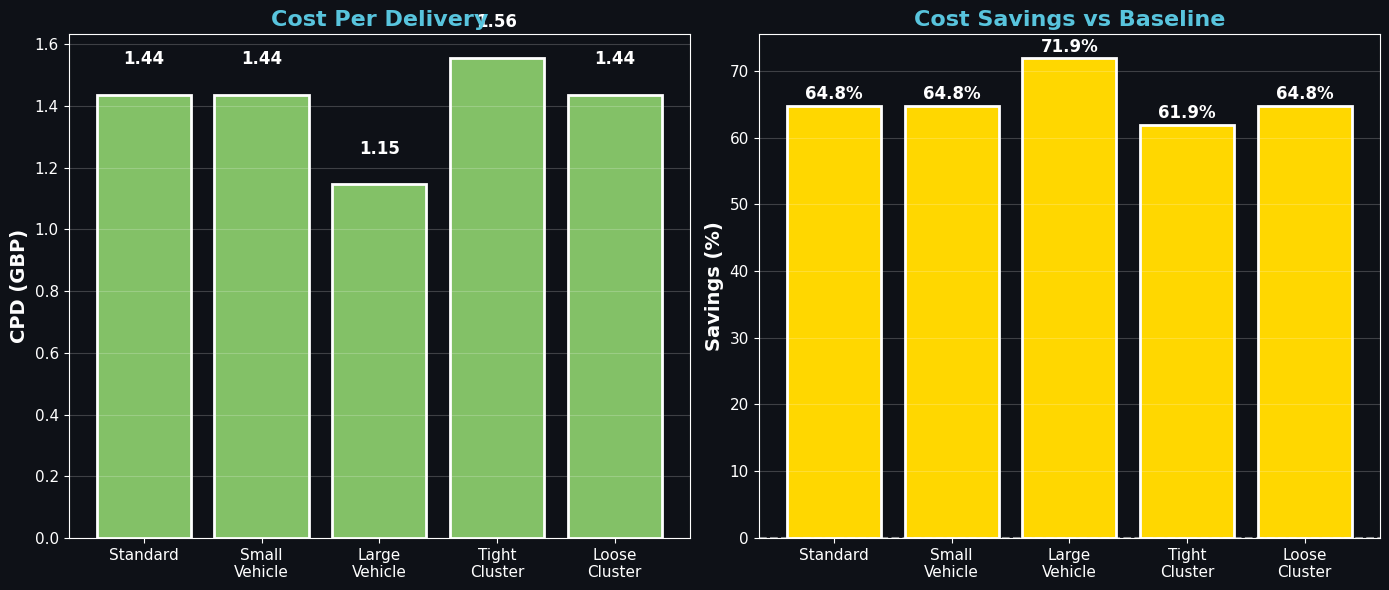


EXPERIMENTATION COMPLETE


In [ ]:
"""
BATCH WINDOW OPTIMIZATION - INTERACTIVE EXPERIMENTATION
========================================================
Play with constraints and see results instantly
"""

import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                      "pulp", "matplotlib", "numpy", "pandas", "ipywidgets"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import *
from datetime import datetime, timedelta
from itertools import combinations, permutations
from ipywidgets import interact, FloatSlider, IntSlider
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
GREEN = '#83C167'
RED = '#FC6255'
CYAN = '#58C4DD'
YELLOW = '#FFD700'

# ============================================================================
# DATA GENERATOR
# ============================================================================

class OrderGenerator:
    def __init__(self, seed=42):
        np.random.seed(seed)
        self.store_lat = 51.5265
        self.store_lon = -0.0823

    def generate(self, n_orders=30, radius_km=3.0, lambda_rate=0.2):
        orders = []
        for i in range(n_orders):
            r = radius_km * np.sqrt(np.random.random())
            theta = 2 * np.pi * np.random.random()
            lat = self.store_lat + r * np.cos(theta) / 111.0
            lon = self.store_lon + r * np.sin(theta) / (111.0 * np.cos(np.radians(self.store_lat)))
            weight = np.random.uniform(0.5, 3.0)

            orders.append({
                'order_id': f'ORD{i+1:03d}',
                'customer_lat': lat,
                'customer_lon': lon,
                'weight_kg': weight
            })
        return pd.DataFrame(orders)

# ============================================================================
# OPTIMIZATION FUNCTIONS
# ============================================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def calc_cost(distance_km, fixed=3.50, variable=0.15):
    return fixed + variable * distance_km

def generate_batches(orders, capacity_kg, max_dist_km, max_batch_size):
    batches = []
    batch_id = 0

    for idx, order in orders.iterrows():
        batches.append({
            'batch_id': batch_id,
            'indices': [idx],
            'weight': order['weight_kg']
        })
        batch_id += 1

    for size in range(2, min(max_batch_size + 1, len(orders) + 1)):
        for combo in combinations(orders.iterrows(), size):
            indices, rows = zip(*combo)
            total_weight = sum(r['weight_kg'] for r in rows)

            if total_weight > capacity_kg:
                continue

            lats = [r['customer_lat'] for r in rows]
            lons = [r['customer_lon'] for r in rows]

            max_dist = 0
            for i in range(len(lats)):
                for j in range(i+1, len(lats)):
                    d = haversine(lats[i], lons[i], lats[j], lons[j])
                    max_dist = max(max_dist, d)

            if max_dist > max_dist_km:
                continue

            batches.append({
                'batch_id': batch_id,
                'indices': list(indices),
                'weight': total_weight
            })
            batch_id += 1

    return batches

def solve_tsp(batch_orders, store_lat, store_lon):
    n = len(batch_orders)

    if n == 1:
        order = batch_orders.iloc[0]
        dist = haversine(store_lat, store_lon, order['customer_lat'], order['customer_lon'])
        return dist * 2

    locs = [(store_lat, store_lon)]
    for _, r in batch_orders.iterrows():
        locs.append((r['customer_lat'], r['customer_lon']))

    n_nodes = len(locs)
    dist_mat = np.zeros((n_nodes, n_nodes))

    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                dist_mat[i][j] = haversine(locs[i][0], locs[i][1], locs[j][0], locs[j][1])

    if n <= 4:
        min_dist = float('inf')
        for perm in permutations(range(1, n_nodes)):
            route = [0] + list(perm) + [0]
            dist = sum(dist_mat[route[i]][route[i+1]] for i in range(len(route)-1))
            min_dist = min(min_dist, dist)
        return min_dist
    else:
        unvisited = set(range(1, n_nodes))
        route = [0]
        current = 0
        while unvisited:
            nearest = min(unvisited, key=lambda j: dist_mat[current][j])
            route.append(nearest)
            unvisited.remove(nearest)
            current = nearest
        route.append(0)
        return sum(dist_mat[route[i]][route[i+1]] for i in range(len(route)-1))

def optimize(orders, capacity_kg, max_dist_km, max_batch_size, store_lat, store_lon):
    batches = generate_batches(orders, capacity_kg, max_dist_km, max_batch_size)

    batch_info = []
    for batch in batches:
        batch_orders = orders.loc[batch['indices']]
        route_dist = solve_tsp(batch_orders, store_lat, store_lon)
        cost = calc_cost(route_dist)

        batch_info.append({
            'batch_id': batch['batch_id'],
            'n_orders': len(batch['indices']),
            'total_cost': cost,
            'cost_per_order': cost / len(batch['indices'])
        })

    assigned = set()
    selected = []

    for batch in sorted(batch_info, key=lambda x: x['cost_per_order']):
        indices = batches[batch['batch_id']]['indices']
        if any(idx in assigned for idx in indices):
            continue
        selected.append(batch)
        assigned.update(indices)
        if len(assigned) == len(orders):
            break

    total_cost = sum(b['total_cost'] for b in selected)
    cpd = total_cost / len(orders)
    batching_rate = sum(1 for b in selected if b['n_orders'] > 1) / len(selected) * 100

    return {
        'cpd': cpd,
        'n_batches': len(selected),
        'batching_rate': batching_rate,
        'total_cost': total_cost
    }

def baseline(orders, store_lat, store_lon):
    total_cost = 0
    for _, order in orders.iterrows():
        dist = haversine(store_lat, store_lon, order['customer_lat'], order['customer_lon'])
        total_cost += calc_cost(dist * 2)

    return {
        'cpd': total_cost / len(orders),
        'n_batches': len(orders),
        'batching_rate': 0,
        'total_cost': total_cost
    }

# ============================================================================
# INTERACTIVE EXPERIMENTATION
# ============================================================================

gen = OrderGenerator(seed=42)
orders = gen.generate(n_orders=30, radius_km=3.0)

def experiment(capacity_kg=20, max_dist_km=5, max_batch_size=3):
    base = baseline(orders, gen.store_lat, gen.store_lon)
    opt = optimize(orders, capacity_kg, max_dist_km, max_batch_size, gen.store_lat, gen.store_lon)

    savings_pct = (1 - opt['cpd'] / base['cpd']) * 100
    de_reduction_pct = (1 - opt['n_batches'] / base['n_batches']) * 100

    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0E1117')
    ax.set_facecolor('#0E1117')

    metrics = ['CPD (GBP)', 'Batches/DEs', 'Batching Rate (%)']
    baseline_vals = [base['cpd'], base['n_batches'], base['batching_rate']]
    optimized_vals = [opt['cpd'], opt['n_batches'], opt['batching_rate']]

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline',
                   color=RED, edgecolor='white', linewidth=2)
    bars2 = ax.bar(x + width/2, optimized_vals, width, label='Optimized',
                   color=GREEN, edgecolor='white', linewidth=2)

    ax.set_ylabel('Value', fontsize=16, color='white', weight='bold')
    ax.set_title('Baseline vs Optimized Batching', fontsize=18,
                color=CYAN, weight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=14, color='white')
    ax.legend(fontsize=14, loc='upper right')
    ax.grid(True, alpha=0.2, axis='y')
    ax.tick_params(colors='white', labelsize=12)

    for i, (b, o) in enumerate(zip(baseline_vals, optimized_vals)):
        ax.text(i - width/2, b + 1, f'{b:.1f}', ha='center',
               fontsize=13, color='white', weight='bold')
        ax.text(i + width/2, o + 1, f'{o:.1f}', ha='center',
               fontsize=13, color='white', weight='bold')

    results_text = f"""
RESULTS:
• Cost Savings: {savings_pct:.1f}%
• DE Reduction: {de_reduction_pct:.1f}%
• Batching Rate: {opt['batching_rate']:.1f}%

PARAMETERS:
• Capacity: {capacity_kg} kg
• Max Distance: {max_dist_km} km
• Max Batch Size: {max_batch_size}
    """

    ax.text(0.98, 0.97, results_text, transform=ax.transAxes,
           fontsize=13, color=YELLOW, weight='bold',
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.9, pad=1))

    plt.tight_layout()
    plt.show()

    print(f"\nBASELINE: GBP {base['cpd']:.2f} per delivery | {base['n_batches']} DEs")
    print(f"OPTIMIZED: GBP {opt['cpd']:.2f} per delivery | {opt['n_batches']} batches")
    print(f"SAVINGS: {savings_pct:.1f}% cost | {de_reduction_pct:.1f}% DEs\n")

print("\n" + "="*60)
print("INTERACTIVE BATCH WINDOW OPTIMIZER")
print("="*60)
print("\nAdjust constraints below and see results instantly:\n")

interact(experiment,
         capacity_kg=IntSlider(min=10, max=40, step=5, value=20,
                              description='Capacity (kg):'),
         max_dist_km=FloatSlider(min=2, max=10, step=0.5, value=5,
                                description='Max Dist (km):'),
         max_batch_size=IntSlider(min=2, max=5, step=1, value=3,
                                 description='Max Batch:'))

# ============================================================================
# WHAT-IF SCENARIOS
# ============================================================================

print("\n" + "="*60)
print("WHAT-IF SCENARIOS")
print("="*60 + "\n")

scenarios = {
    'Standard (20kg, 5km, batch=3)': (20, 5, 3),
    'Small Vehicle (15kg, 5km, batch=3)': (15, 5, 3),
    'Large Vehicle (30kg, 5km, batch=4)': (30, 5, 4),
    'Tight Clustering (20kg, 3km, batch=3)': (20, 3, 3),
    'Loose Clustering (20kg, 8km, batch=3)': (20, 8, 3),
}

results = []
base = baseline(orders, gen.store_lat, gen.store_lon)

for name, (cap, dist, batch) in scenarios.items():
    opt = optimize(orders, cap, dist, batch, gen.store_lat, gen.store_lon)
    savings = (1 - opt['cpd'] / base['cpd']) * 100
    results.append({
        'Scenario': name,
        'CPD': opt['cpd'],
        'Batches': opt['n_batches'],
        'Batching %': opt['batching_rate'],
        'Savings %': savings
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0E1117')

for ax in axes:
    ax.set_facecolor('#0E1117')

scenarios_short = ['Standard', 'Small\nVehicle', 'Large\nVehicle',
                   'Tight\nCluster', 'Loose\nCluster']
cpds = df_results['CPD'].values
savings = df_results['Savings %'].values

axes[0].bar(scenarios_short, cpds, color=GREEN, edgecolor='white', linewidth=2)
axes[0].set_ylabel('CPD (GBP)', fontsize=14, color='white', weight='bold')
axes[0].set_title('Cost Per Delivery', fontsize=16, color=CYAN, weight='bold')
axes[0].tick_params(colors='white', labelsize=11)
axes[0].grid(True, alpha=0.2, axis='y')

for i, v in enumerate(cpds):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center',
                fontsize=12, color='white', weight='bold')

axes[1].bar(scenarios_short, savings, color=YELLOW, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Savings (%)', fontsize=14, color='white', weight='bold')
axes[1].set_title('Cost Savings vs Baseline', fontsize=16, color=CYAN, weight='bold')
axes[1].tick_params(colors='white', labelsize=11)
axes[1].grid(True, alpha=0.2, axis='y')
axes[1].axhline(y=0, color='white', linestyle='--', alpha=0.5)

for i, v in enumerate(savings):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center',
                fontsize=12, color='white', weight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EXPERIMENTATION COMPLETE")
print("="*60)